# Lab Assignment: Generative AI

#### Lab team: 20

##### Name (member 1): Sandra Yunta Martin

##### Name (member 2): Maya Ceamanos Lopez-Sanvicente

* Please include your full name at the beginning of all submitted files.
* Make sure the presentation is well-structured: the report will be evaluated not only for correctness, but also for clarity, conciseness, and completeness.
* Make use of figures and tables to summarize the results and illustrate the discussions.
* If external material is used, the sources must be cited. 
* Include references in APA format https://pitt.libguides.com/citationhelp/apa7. Lack or poorly formatted references can be penalized.
* A generative AI tool can be used for consultation. You must specify the tool used in your report.
* You are not allowed to use a generative AI tool to generate code.

Submit a single `.zip` file, whose name has the format `AA3_2024_2025_P02_teamCode_lastName1_lastName2.zip` 
The name must not include graphical accents, spaces, uppercase letters, or special characters.

For example: `AA3_2024_2025_P02_V03_munyoz_deLaRosa.zip`

This compressed file must include the following files:

* This Python notebook with the solutions of the exercises. The notebook should include only code snippets, figures, tables, derviations and explanations (with LaTex if necessary) in Markdown cells. Handwritten material can be included in the Python notebook as images. Functions should be defined in a separate `.py` file, not in the notebook.
* The necessary `.py` and addional files to ensure the Python notebook code can be executed sequentially without errors.
* A PDF file generated from the notebook (Export the notebook as an HTML file. Open the HTML file in a Browser and print it as a PDF file). 

Make sure that all the code cells can be executed squentially without errors (Kernel -> Restart & Run All). Exectution and formatting errors will be penalized.

The grade of this lab assignment is based on
* This submission (50 %).
* An individual in-class exam (50%).


Evaluation criteria:
* [6 points] Quality of the report (correctness, clarity, conciseness, completeness).
* [3 points] Quality of the code (correctness, adherence to a Python style guide -for instance, Google's-, comments, functional decomposition).
* [1 point]  References.                                                                   

## References:

1. Yang Song, Jascha Sohl-Dickstein, Diederik P. Kingma, Abhishek Kumar, Stefano Ermon and Ben Poole
"Score-Based Generative Modeling through Stochastic Differential Equations"
In International Conference on Learning Representations, 2021
https://arxiv.org/abs/2011.13456
2. TODO: Include references in alphabetical order

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from functools import partial 

import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

import diffusion_process as dfp

from diffusion_utilities import (
    plot_image_grid,
    plot_image_evolution,
    animation_images,
)

from score_model import ScoreNet, ConditionalScoreNet

import matplotlib.pyplot as plt

from FID import InceptionFeatureExtractor, get_features_from_loader, get_features_from_tensor, compute_statistics, calculate_fid_from_stats, compute_statistics

n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

# device ='cpu'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Number of threads: 8


## Exercise 1:  Generative AI based on diffusion models: Brownian motion 

In this exercise the training data is generated by injectiong noise using Brownian motion (variance exploding diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t) 
$$

with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$, and  $\sigma > 0 $.
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary $t$?  

Given the SDE  
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t), \qquad \mathbf{x}(0)=\mathbf{x}_0
$$
the mean is
$$
\mathbb{E}[\mathbf{x}(t)\mid \mathbf{x}_0] = \mathbf{x}_0
$$
and the variance is
$$
\mathrm{Var}[\mathbf{x}(t)\mid \mathbf{x}_0]
= \int_0^t \sigma^{2s}\, ds \, \mathbf{I}
= \frac{\sigma^{2t}-1}{2\log \sigma}\, \mathbf{I}
$$
Therefore,
$$
\mathbf{x}(t)\mid \mathbf{x}_0 
\sim 
\mathcal{N}\left(
\mathbf{x}_0,\;
\frac{\sigma^{2t}-1}{2\log \sigma}\,\mathbf{I}
\right)
$$

2. What is the SDE for the time-reversed process?  

The reverse-time SDE is given by
$$
d\mathbf{x}(t)
=
\left(
\mathbf{f}(\mathbf{x}(t),t)
-
g^2(t)\nabla_{\mathbf{x}} \log p_t(\mathbf{x})
\right) dt
+
g(t)\, d\mathbf{W}(t)
$$

In this case,
$$
\mathbf{f}(\mathbf{x}(t),t)=0,
\qquad
g(t)=\sigma^t
$$

Therefore, the reverse SDE is
$$
d\mathbf{x}(t)
=
-\sigma^{2t}\nabla_{\mathbf{x}} \log p_t(\mathbf{x})\, dt
+
\sigma^t\, d\mathbf{W}(t)
$$  

3. For the synthesis of new images

    1. In what interval is the reverse process SDE integrated?  

    The reverse SDE is integrated backward in time:
    $$
    t \in [T, 0]
    $$

    In practice, it is integrated from $T$ to a small value $\varepsilon > 0$ for numerical stability:
    $$
    t \in [T, \varepsilon]
    $$

    2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled?  

    The initial condition is sampled from a Gaussian distribution that approximates $p_T(\mathbf{x})$:
    $$
    \pi(\mathbf{x}) = \mathcal{N}(0, \sigma_T^2 \mathbf{I})
    $$  

    where  
    $$
    \sigma_T^2 = \int_0^T \sigma^{2s}\, ds
    = \frac{\sigma^{2T}-1}{2\log \sigma}
    $$

### Exercise 1.1:  Training the model by weighted sum of denoising score matching objectives
1. Give the mathematical form and explain the cost function used in the training of the generative AI model.  

The neural network $\mathbf{s}(\mathbf{x},t;\theta)$ approximates the time-dependent score function
$$
\mathbf{s}(\mathbf{x},t;\theta)\approx \nabla_{\mathbf{x}} \log p_t(\mathbf{x})
$$

For a Gaussian process,
$$
\mathbf{x}_t = \mu_t(\mathbf{x}_0) + \sigma_t \mathbf{z}, \qquad \mathbf{z}\sim \mathcal{N}(0,\mathbf{I})
$$

the exact conditional score is
$$
\nabla_{\mathbf{x}_t}\log p_{t|0}(\mathbf{x}_t|\mathbf{x}_0)
=
-\frac{1}{\sigma_t}\mathbf{z}
$$

Therefore, the cost function can be written as
$$
\mathcal{L}(\theta)
=
\mathbb{E}
\left[
\left\|
\mathbf{s}(\mathbf{x}_t,t;\theta)+\frac{\mathbf{z}}{\sigma_t}
\right\|^2
\right]
$$

Equivalently, the reweighted form is used
$$
\mathcal{L}(\theta)
=
\mathbb{E}
\left[
\left\|
\sigma_t\,\mathbf{s}(\mathbf{x}_t,t;\theta)+\mathbf{z}
\right\|^2
\right]
$$

2. Indicate what type of neural network is used to model the score, its inputs, outputs, and architecture.   

A time-dependent U-Net convolutional neural network is used.

Inputs:
$$
(\mathbf{x}_t, t)
$$

Output:
$$
\mathbf{s}(\mathbf{x}_t,t;\theta)
$$

The architecture includes:
- convolutional layers and transposed convolutions,
- normalization using GroupNorm,
- swish activation,
- skip connections between encoder and decoder,
- injection of temporal information at different layers.  

3. Explain how time is input in the neural network model for the time-dependent score function using random Fourier features.  

Time $t$ is transformed using Gaussian random Fourier features:
$$
\phi(t)=
\left[
\sin(2\pi t\mathbf{w}),
\cos(2\pi t\mathbf{w})
\right],
\qquad \mathbf{w}\sim \mathcal{N}(0,\mathbf{I})
$$

This embedding is introduced into the network through dense layers and combined with the internal representations.

4. Illustrate how to train a model to generate handwritten digits for the MNIST dataset using the Brownian motion diffusion model.  
This first block of code should run in less than 5 minutes.  

The forward SDE used is:
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t)
$$

with
$$
\mu_t(\mathbf{x}_0)=\mathbf{x}_0,
\qquad
\sigma_t^2 = \int_0^t \sigma^{2s} ds
= \frac{\sigma^{2t}-1}{2\log \sigma}
$$

The training procedure consists of:

- sampling $\mathbf{x}_0$ from the dataset (MNIST),
- sampling $t \sim U(\varepsilon,1)$,
- generating noise $\mathbf{z}\sim \mathcal{N}(0,\mathbf{I})$,
- constructing
$$
\mathbf{x}_t = \mu_t(\mathbf{x}_0) + \sigma_t \mathbf{z}
$$
- evaluating the network $\mathbf{s}(\mathbf{x}_t,t;\theta)$,
- computing the loss,
- updating the parameters using an optimizer (Adam).

This procedure is repeated over mini-batches for several training epochs.

In [2]:
# Dataset MINST
data_train_full = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

# Subconjunto para que el bloque tarde menos de 5 minutos
subset_size = 5000
data_train = Subset(data_train_full, range(subset_size))

In [3]:
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)  # drift term: f(x_t, t) = 0

def bm_diffusion_coefficient(t, sigma):
    return sigma**t  # diffusion coefficient: g(t) = sigma^t

def bm_mu_t(x_0, t):
    return x_0  # conditional mean: mu_t(x_0) = x_0

def bm_sigma_t(t, sigma):
    return torch.sqrt(0.5 * (sigma**(2 * t) - 1.0) / np.log(sigma))
    # sigma_t = sqrt(integral_de_0-t (g(s)^2 ds))

drift_coefficient = bm_drift_coefficient
diffusion_coefficient = lambda t: bm_diffusion_coefficient(t, sigma)
mu_t = bm_mu_t
sigma_t = lambda t: bm_sigma_t(t, sigma)

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
)

In [4]:
# Define the score model

from score_model import ScoreNet

# creates the neural network s_theta(x, t) ≈ grad_x log p_t(x)

score_model = torch.nn.DataParallel( # allows using multiple GPUs simultaneously, if available
    ScoreNet(
        # neural network that receives noisy image, x_t, time t, and returns the score s(x, t) = grad_x log p_t(x)
        marginal_prob_std=partial(bm_sigma_t, sigma=sigma) # partial allows fixing the value of sigma in the function bm_sigma_t
    )
)
score_model = score_model.to(device)

In [5]:
# Train the network to learn the score function (interpretation as denoising)

from torch.optim import Adam
import torchvision.transforms as transforms
from tqdm import trange  # progress bars

batch_size = 32

# Divide the training data into mini-batches
data_loader = DataLoader(
    data_train,
    batch_size=batch_size,  # processes 32 images in each iteration
    shuffle=True,           # shuffles the data in each epoch to improve learning
    num_workers=n_threads,  # number of parallel processes to load the data
)

learning_rate = 1.0e-3
optimizer = Adam(
    score_model.parameters(),
    lr=learning_rate
)  # Adam optimizer to update the model parameters

n_epochs = 10  # number of training epochs
tqdm_epoch = trange(n_epochs)  # progress bar to visualize the epochs

for epoch in tqdm_epoch:  # loop over the training epochs
    avg_loss = 0.0        # accumulator for the total loss in the epoch
    num_items = 0         # total number of samples processed

    for x, y in data_loader:  # iteration over the mini-batches (x: images, y: labels)
        x = x.to(device)      # moves the images to the device (CPU or GPU)

        loss = diffusion_process.loss_function(score_model, x)
        # calculates the loss function:
        # t is sampled, x_t is generated by adding noise,
        # the network predicts the score and the denoising error is calculated

        optimizer.zero_grad()  # resets the accumulated gradients
        loss.backward()        # calculates the gradients of the loss with respect to the model parameters
        optimizer.step()       # updates the model parameters using the optimizer

        avg_loss += loss.item() * x.shape[0]
        # loss.item() converts the tensor to a scalar
        # it is multiplied by the batch size to accumulate the total loss

        num_items += x.shape[0]  # accumulates the total number of samples processed

    tqdm_epoch.set_description(
        'Average Loss: {:5f}'.format(avg_loss / num_items)
    )  # displays the average loss of the epoch in the progress bar

    torch.save(score_model.state_dict(), 'check_point_fast.pth')
    # saves the state of the model (learned parameters)

Average Loss: 38.637297: 100%|██████████| 10/10 [00:59<00:00,  6.00s/it]


### Exercise 1.2: Generation using the Euler-Maruyama integrator
Use a model that you have previously trained (not the one in the previous exercise) high-quality model to generate some samples using the Euler-Maruyama integrator.

C:\Users\sandr\AppData\Local\Temp\ipykernel_22212\3460269965.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  check_point = torch.load("check_point.pth", map_location=de

Shape of generated trajectories: torch.Size([9, 1, 28, 28, 501])


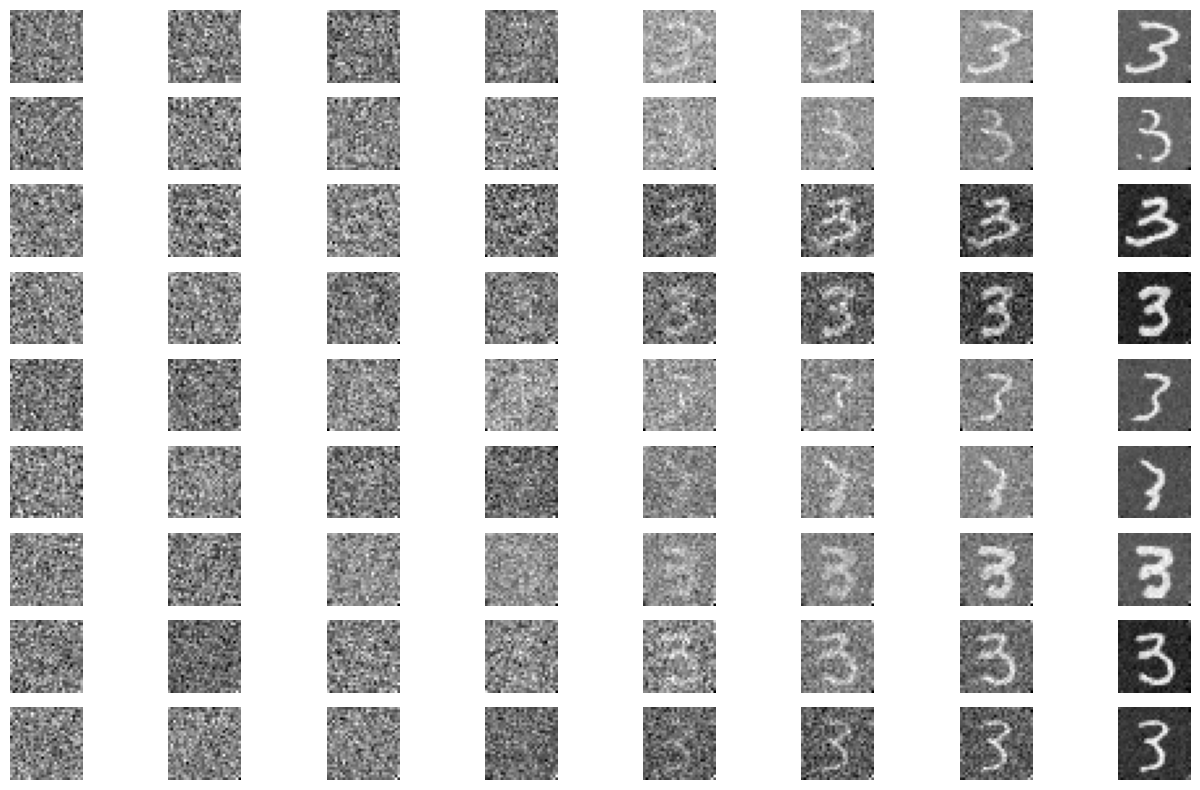

In [6]:
import torch
import numpy as np
from functools import partial
from collections import OrderedDict

import diffusion_process as dfp
from score_model import ScoreNet
from diffusion_utilities import plot_image_evolution

# --------------------------------------------------
# Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Brownian motion VE model used in the professor demo
# Forward SDE: dx(t) = sigma^t dW(t)
# --------------------------------------------------
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)

def bm_diffusion_coefficient(t, sigma):
    return sigma ** t

def bm_mu_t(x_0, t):
    return x_0

def bm_sigma_t(t, sigma):
    return torch.sqrt(0.5 * (sigma ** (2 * t) - 1.0) / np.log(sigma))

drift_coefficient = bm_drift_coefficient
diffusion_coefficient = partial(bm_diffusion_coefficient, sigma=sigma)
mu_t = bm_mu_t
sigma_t = partial(bm_sigma_t, sigma=sigma)

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

# --------------------------------------------------
# Score model
# --------------------------------------------------
score_model = ScoreNet(
    marginal_prob_std=partial(bm_sigma_t, sigma=sigma)
).to(device)

# --------------------------------------------------
# Load pretrained checkpoint from the good demo
# --------------------------------------------------
check_point = torch.load("check_point.pth", map_location=device)

# Robust loading: remove "module." if checkpoint was saved with DataParallel
new_state_dict = OrderedDict()
for k, v in check_point.items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v

score_model.load_state_dict(new_state_dict)
score_model.eval()

# --------------------------------------------------
# Reverse SDE for Euler-Maruyama
# dx = [f(x,t) - g(t)^2 s_theta(x,t)] dt + g(t) dW
# Here f(x,t)=0 and g(t)=sigma^t
# --------------------------------------------------
def backward_drift_coefficient(x_t, t, diffusion_coefficient, score_model):
    g_t = diffusion_coefficient(t).view(-1, 1, 1, 1)
    return drift_coefficient(x_t, t) - (g_t ** 2) * score_model(x_t, t)

# --------------------------------------------------
# Sampling
# --------------------------------------------------
n_images = 9
T = 1.0
eps = 1.0e-3
n_steps = 500

# Initial condition x(T) ~ N(0, sigma_T^2 I)
sigma_T = bm_sigma_t(torch.ones(n_images, device=device) * T, sigma).view(-1, 1, 1, 1)
image_T = torch.randn(n_images, 1, 28, 28, device=device) * sigma_T

with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        x_0=image_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_coefficient,
            diffusion_coefficient=diffusion_coefficient,
            score_model=score_model,
        ),
        diffusion_coefficient=diffusion_coefficient,
    )

print("Shape of generated trajectories:", synthetic_images_t.shape)

# --------------------------------------------------
# Visualization of the trajectory
# --------------------------------------------------
_ = plot_image_evolution(
    images=synthetic_images_t.detach().cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 480, 500],
    figsize=(16, 10),
)

### Exercise 1.3: Generation using a probability flow ODE.
1. Explain what is the Fokker-Planck equation and in what way is it related to an SDE.  

Let the forward SDE be

$$
d\mathbf{x}(t)=\mathbf{f}(\mathbf{x}(t),t)\,dt+g(t)\,d\mathbf{W}(t),
$$

where $\mathbf{f}(\mathbf{x},t)$ is the drift term and $g(t)$ is the diffusion coefficient.
If $p_t(\mathbf{x})$ denotes the probability density of $\mathbf{x}(t)$, then its time evolution is given by the Fokker-Planck equation:

$$
\frac{\partial p_t(\mathbf{x})}{\partial t}
=
-\nabla_{\mathbf{x}}\cdot\left(\mathbf{f}(\mathbf{x},t)\,p_t(\mathbf{x})\right)
+
\frac{1}{2}g(t)^2 \,\Delta_{\mathbf{x}} p_t(\mathbf{x}),
$$

where $\nabla_{\mathbf{x}}\cdot$ is the divergence and $\Delta_{\mathbf{x}}$ is the Laplacian with respect to $\mathbf{x}$.

Therefore, the Fokker-Planck equation describes how the probability density associated with an SDE evolves over time. In other words, the SDE describes the dynamics of individual trajectories, while the Fokker-Planck equation describes the dynamics of the probability distribution of those trajectories.

2. Explain how the probability flow ODE can be used to generate samples from $p_0\left(\mathbf{x} \right)$.  

There exists an ordinary differential equation (ODE), called the \emph{probability flow ODE}, which shares the same marginal distributions $p_t(\mathbf{x})$ as the previous SDE. This ODE is given by

$$
\frac{d\mathbf{x}(t)}{dt}
=
\mathbf{f}(\mathbf{x}(t),t)
-
\frac{1}{2}g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x}(t)).
$$

In practice, the true score $\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ is unknown, and it is replaced by the approximation learned by the neural network,
$s_\theta(\mathbf{x},t)\approx \nabla_{\mathbf{x}} \log p_t(\mathbf{x})$.
Thus, the ODE used for generation is

$$
\frac{d\mathbf{x}(t)}{dt}
=
\mathbf{f}(\mathbf{x}(t),t)
-
\frac{1}{2}g(t)^2 s_\theta(\mathbf{x}(t),t).
$$

To generate new images, an initial condition $\mathbf{x}(T)$ is sampled from a simple known distribution $\pi(\mathbf{x})$, which closely approximates $p_T(\mathbf{x})$, and the ODE is integrated backward in time, from $T$ to a small value $\varepsilon \approx 0$.
The final result is a synthetic sample approximately distributed according to $p_0(\mathbf{x})$.

In the case of the Brownian model used in this practice, we have

$$
\mathbf{f}(\mathbf{x},t)=\mathbf{0},
\qquad
g(t)=\sigma^t,
$$

so the probability flow ODE becomes

$$
\frac{d\mathbf{x}(t)}{dt}
=
-\frac{1}{2}\sigma^{2t}\, s_\theta(\mathbf{x}(t),t).
$$

3. Implement and illustrate the use of this method to generate synthetic images of handwritten digits.

In [7]:
# Full MNIST dataset: all digits 0-9
batch_size = 64

data_loader_full = DataLoader(
    data_train_full,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [8]:
# --------------------------------------------------
# Brownian motion / VE process
# --------------------------------------------------
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)

def bm_diffusion_coefficient(t, sigma):
    return sigma ** t

def bm_mu_t(x_0, t):
    return x_0

def bm_sigma_t(t, sigma):
    return torch.sqrt(0.5 * (sigma ** (2 * t) - 1.0) / np.log(sigma))

drift_brownian = bm_drift_coefficient
diffusion_brownian = partial(bm_diffusion_coefficient, sigma=sigma)
mu_brownian = bm_mu_t
sigma_brownian = partial(bm_sigma_t, sigma=sigma)

diffusion_process_brownian = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_brownian,
    diffusion_coefficient=diffusion_brownian,
    mu_t=mu_brownian,
    sigma_t=sigma_brownian,
)

In [9]:
# --------------------------------------------------
# Conditional loss
# --------------------------------------------------
def conditional_loss_function(diffusion_process, score_model, x_0, y, eps=1e-5):
    t = torch.rand(x_0.shape[0], device=x_0.device) * (1.0 - eps) + eps
    z = torch.randn_like(x_0)

    sigma_t_batch = diffusion_process.sigma_t(t).view(-1, 1, 1, 1)
    mu_t_batch = diffusion_process.mu_t(x_0, t)

    x_t = mu_t_batch + sigma_t_batch * z

    score = score_model(x_t, t, y)

    loss = torch.mean(
        torch.sum((sigma_t_batch * score + z) ** 2, dim=(1, 2, 3))
    )

    return loss

In [10]:
# --------------------------------------------------
# Conditional score model
# --------------------------------------------------
score_model_brownian_cond = ConditionalScoreNet(
    marginal_prob_std=sigma_brownian,
    in_channels=1,
    num_classes=10
).to(device)

In [11]:
def probability_flow_drift_brownian_conditional(x_t, t, y):
    g_t = diffusion_brownian(t).view(-1, 1, 1, 1)
    return drift_brownian(x_t, t) - 0.5 * (g_t ** 2) * score_model_brownian_cond(x_t, t, y)

def euler_ode_integrator_conditional(x_0, y, t_0, t_end, n_steps, drift_fn):
    device = x_0.device
    times = torch.linspace(t_0, t_end, n_steps + 1, device=device)
    dt = times[1] - times[0]

    x_t = torch.empty(*x_0.shape, len(times), device=device)
    x_t[..., 0] = x_0

    for n, t_scalar in enumerate(times[:-1]):
        t_batch = torch.ones(x_0.shape[0], device=device) * t_scalar
        x_t[..., n + 1] = x_t[..., n] + drift_fn(x_t[..., n], t_batch, y) * dt

    return times, x_t

# FOR FID
def generate_brownian_conditional_samples(
    score_model,
    n_samples=300,
    T=1.0,
    eps=1e-3,
    n_steps=200,
    batch_size=64,
):
    score_model.eval()
    all_samples = []

    num_batches = int(np.ceil(n_samples / batch_size))

    for batch_idx in range(num_batches):
        current_batch_size = min(batch_size, n_samples - batch_idx * batch_size)

        # Labels balanced: 0,1,2,...,9,0,1,...
        y = torch.arange(current_batch_size, device=device) % 10

        sigma_T = bm_sigma_t(
            torch.ones(current_batch_size, device=device) * T,
            sigma
        ).view(-1, 1, 1, 1)

        x_T = torch.randn(
            current_batch_size,
            1,
            28,
            28,
            device=device
        ) * sigma_T

        with torch.no_grad():
            _, synthetic_images = euler_ode_integrator_conditional(
                x_0=x_T,
                y=y,
                t_0=T,
                t_end=eps,
                n_steps=n_steps,
                drift_fn=probability_flow_drift_brownian_conditional,
            )

        samples = synthetic_images[..., -1]
        samples = torch.clamp(samples, 0.0, 1.0)

        all_samples.append(samples.detach().cpu())

    return torch.cat(all_samples, dim=0)[:n_samples]

In [12]:
# --------------------------------------------------
# Real statistics for FID
# --------------------------------------------------
feature_extractor = InceptionFeatureExtractor(device)

real_features = get_features_from_loader(
    data_loader_full,
    feature_extractor,
    device,
    max_batches=20
)

mu_real, sigma_real_stats = compute_statistics(real_features)

print("Real FID stats computed:", mu_real.shape, sigma_real_stats.shape)

Real FID stats computed: (2048,) (2048, 2048)


In [13]:
learning_rate = 1e-4
optimizer_brownian_cond = Adam(score_model_brownian_cond.parameters(), lr=learning_rate)

n_epochs_brownian = 100
tqdm_epoch = trange(n_epochs_brownian)

best_loss = float("inf")
loss_history_cond = []

# for FID
fid_history_brownian = []
fid_epochs_brownian = []

for epoch in tqdm_epoch:
    score_model_brownian_cond.train()
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader_full:
        x = x.to(device)
        y = y.to(device)

        loss = conditional_loss_function(
            diffusion_process_brownian,
            score_model_brownian_cond,
            x,
            y
        )

        optimizer_brownian_cond.zero_grad()
        loss.backward()
        optimizer_brownian_cond.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history_cond.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(
            score_model_brownian_cond.state_dict(),
            "check_point_brownian_conditional_mnist.pth"
        )

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:.6f}")

    # --------------------------------------------
    # FID
    # --------------------------------------------
    if (epoch + 1) % 10 == 0:
        gen_brownian = generate_brownian_conditional_samples(
            score_model=score_model_brownian_cond,
            n_samples=300,
            T=1.0,
            eps=1e-3,
            n_steps=200,
            batch_size=64,
        )

        gen_features = get_features_from_tensor(
            gen_brownian,
            feature_extractor,
            device,
            batch_size=64
        )

        mu_gen, sigma_gen_stats = compute_statistics(gen_features)

        fid_value = calculate_fid_from_stats(
            mu_real,
            sigma_real_stats,
            mu_gen,
            sigma_gen_stats
        )

        fid_history_brownian.append(fid_value)
        fid_epochs_brownian.append(epoch + 1)

        print(f"Epoch {epoch + 1} | FID Brownian: {fid_value:.4f}")

Average Loss: 29.121940:  10%|█         | 10/100 [02:13<23:37, 15.75s/it]

Epoch 10 | FID Brownian: 166.9105


Average Loss: 21.327972:  20%|██        | 20/100 [04:25<20:48, 15.61s/it]

Epoch 20 | FID Brownian: 130.9816


Average Loss: 18.994054:  30%|███       | 30/100 [06:38<18:31, 15.88s/it]

...

Epoch 80 | FID Brownian: 115.4580


Average Loss: 16.075670:  90%|█████████ | 90/100 [19:54<02:39, 15.93s/it]

Epoch 90 | FID Brownian: 118.0607


Average Loss: 15.758143: 100%|██████████| 100/100 [22:06<00:00, 13.27s/it]

Epoch 100 | FID Brownian: 117.4965


In [14]:
# ==================================================
# Conditional probability flow ODE sampling
# ==================================================

score_model_brownian_cond.load_state_dict(
    torch.load("check_point_brownian_conditional_mnist.pth", map_location=device)
)
score_model_brownian_cond.eval()


n_images = 10
T = 1.0
eps = 1e-3
n_steps = 500

# Labels 0,1,2,...,9
y_cond = torch.arange(10, device=device)

sigma_T = bm_sigma_t(
    torch.ones(n_images, device=device) * T,
    sigma
).view(-1, 1, 1, 1)

torch.manual_seed(42)
x_T = torch.randn(n_images, 1, 28, 28, device=device) * sigma_T

with torch.no_grad():
    times_ode, synthetic_images_ode_cond = euler_ode_integrator_conditional(
        x_0=x_T,
        y=y_cond,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_fn=probability_flow_drift_brownian_conditional,
    )

C:\Users\sandr\AppData\Local\Temp\ipykernel_22212\3858096539.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("check_point_brownian_conditional_mnist.pth", map

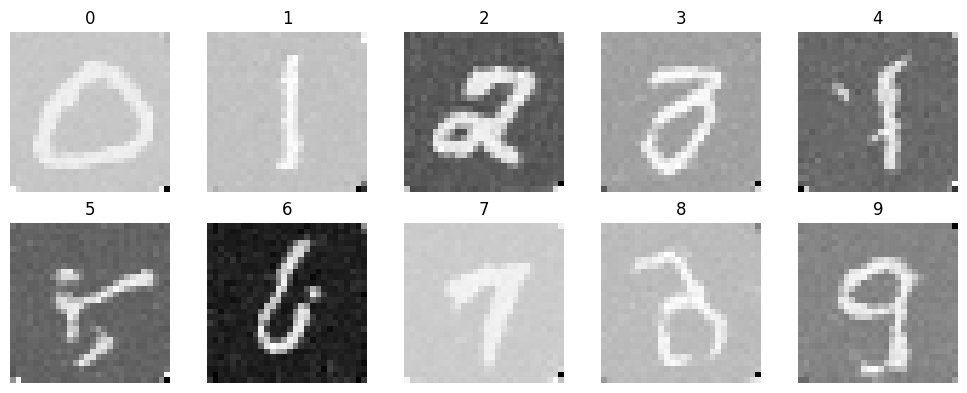

In [15]:
samples_cond = synthetic_images_ode_cond[..., -1].detach().cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(samples_cond[i, 0], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(str(i))

plt.tight_layout()
plt.show()

4. Indicate how to use this scheme to compute likelihoods. Implement this functionality and illustrate its use.  

One advantage of the probability flow ODE is that it allows likelihood computation, which is not straightforward with the reverse SDE.
If we define the velocity field

$$
\widetilde{\mathbf{f}}(\mathbf{x},t)
=
\mathbf{f}(\mathbf{x},t)
-
\frac{1}{2}g(t)^2 s_\theta(\mathbf{x},t),
$$

then the evolution of the log-density along the trajectory satisfies

$$
\frac{d}{dt}\log p_t(\mathbf{x}(t))
=
-
\nabla_{\mathbf{x}}\cdot \widetilde{\mathbf{f}}(\mathbf{x}(t),t).
$$

Therefore, by jointly integrating the trajectory $\mathbf{x}(t)$ and the log-density, one obtains

$$
\log p_0(\mathbf{x}(0))
=
\log p_T(\mathbf{x}(T))
+
\int_0^T
\nabla_{\mathbf{x}}\cdot \widetilde{\mathbf{f}}(\mathbf{x}(t),t)\,dt.
$$

In practice, $\log p_T(\mathbf{x}(T))$ can be computed because at the final time the distribution is approximately a known Gaussian, and the divergence of the field is estimated numerically, usually using the Hutchinson estimator.

In [16]:
def gaussian_logpdf(x, std):
    """
    Log-density of a centered isotropic Gaussian N(0, std^2 I).
    x:   (batch, channels, H, W)
    std: (batch, 1, 1, 1)
    """
    dim = x[0].numel()
    x_flat = x.view(x.shape[0], -1)
    var = (std.view(-1) ** 2)
    return -0.5 * (
        dim * torch.log(2 * torch.tensor(np.pi, device=x.device))
        + dim * torch.log(var)
        + torch.sum(x_flat ** 2, dim=1) / var
    )

def divergence_hutchinson(fn, x, t):
    """
    Hutchinson estimator of divergence:
    div f(x) ≈ eps^T J_f(x) eps
    """
    eps = torch.randn_like(x)
    x.requires_grad_(True)

    y = fn(x, t)
    inner = torch.sum(y * eps)

    grad = torch.autograd.grad(inner, x, create_graph=False)[0]
    div = torch.sum(grad * eps, dim=(1, 2, 3))

    return div

def probability_flow_drift_autograd(x_t, t, y):
    g_t = diffusion_brownian(t).view(-1, 1, 1, 1)
    return drift_brownian(x_t, t) - 0.5 * (g_t ** 2) * score_model_brownian_cond(x_t, t, y)

def compute_log_likelihood_conditional(x_data, y_data, T=1.0, eps=1e-3, n_steps=200):
    score_model_brownian_cond.eval()

    device = x_data.device
    batch_size = x_data.shape[0]

    times = torch.linspace(eps, T, n_steps + 1, device=device)
    dt = times[1] - times[0]

    x = x_data.clone().to(device)
    y = y_data.to(device)

    delta_logp = torch.zeros(batch_size, device=device)

    for t_scalar in times[:-1]:
        t_batch = torch.ones(batch_size, device=device) * t_scalar

        x = x.detach().requires_grad_(True)

        def drift_fn(x_in, t_in):
            return probability_flow_drift_autograd(x_in, t_in, y)

        drift = drift_fn(x, t_batch)
        div = divergence_hutchinson(drift_fn, x, t_batch)

        x = (x + drift * dt).detach()
        delta_logp = delta_logp - div.detach() * dt

    sigma_T = bm_sigma_t(
        torch.ones(batch_size, device=device) * T,
        sigma
    ).view(-1, 1, 1, 1)

    log_pT = gaussian_logpdf(x, sigma_T)
    log_p0 = log_pT + delta_logp

    return log_p0

In [17]:
# Example: compute likelihoods for a mini-batch
x_batch, y_batch = next(iter(data_loader_full))
x_batch = x_batch[:8].to(device)
y_batch = y_batch[:8].to(device)

log_likelihoods = compute_log_likelihood_conditional(
    x_batch,
    y_batch,
    T=1.0,
    eps=1e-3,
    n_steps=500
)

print(log_likelihoods)
print("Average conditional log-likelihood:", log_likelihoods.mean().item())

tensor([-7193.8188, -7186.8457, -7020.2603, -7117.5996, -7014.5605, -7206.9517,
        -7179.7578, -7198.9819], device='cuda:0')
Average conditional log-likelihood: -7139.8466796875


## Exercise 2:  Generative AI based on diffusion models: The Ornstein-Uhlenbeck process

In this exercise, the training data is generated by injecting noise using an Ornstein-Uhlenbeck process (variance preserving diffusion model).
The stochastic differential equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = - \frac{1}{2} \beta(t) \mathbf{x}(t)\,dt + \sqrt{\beta(t)}\, d\mathbf{W}(t)
$$
with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$.

1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary $t$?

Let
$$
A(t) = \int_0^t \beta(s)\,ds.
$$

The previous SDE is linear, so it can be solved by using the integrating factor
$$
e^{\frac{1}{2}A(t)}.
$$

Multiplying the SDE by this factor and integrating from $0$ to $t$, we obtain
$$
\mathbf{x}(t)
=
e^{-\frac{1}{2}A(t)}\mathbf{x}_0
+
\int_0^t e^{-\frac{1}{2}(A(t)-A(s))}\sqrt{\beta(s)}\, d\mathbf{W}(s).
$$

Therefore, conditioned on $\mathbf{x}(0)=\mathbf{x}_0$, the random variable $\mathbf{x}(t)$ is Gaussian:
$$
\mathbf{x}(t)\mid \mathbf{x}_0
\sim
\mathcal{N}\left(\boldsymbol{\mu}_t(\mathbf{x}_0),\,\sigma_t^2 \mathbf{I}\right),
$$
where the conditional mean is
$$
\boldsymbol{\mu}_t(\mathbf{x}_0)
=
e^{-\frac{1}{2}A(t)}\mathbf{x}_0
$$
and the conditional covariance is
$$
\sigma_t^2 \mathbf{I}
=
\left(
\int_0^t e^{-(A(t)-A(s))}\beta(s)\,ds
\right)\mathbf{I}.
$$

Now,
$$
\frac{d}{ds}\left(e^{-(A(t)-A(s))}\right)
=
e^{-(A(t)-A(s))}\beta(s),
$$
so
$$
\int_0^t e^{-(A(t)-A(s))}\beta(s)\,ds
=
1-e^{-A(t)}.
$$

Hence,
$$
\mathbf{x}(t)\mid \mathbf{x}_0
\sim
\mathcal{N}\left(
e^{-\frac{1}{2}A(t)}\mathbf{x}_0,\,
\left(1-e^{-A(t)}\right)\mathbf{I}
\right).
$$

If we define
$$
\alpha(t)=e^{-\frac{1}{2}A(t)},
$$
then the previous expression can be written in the standard variance-preserving form
$$
\mathbf{x}(t)\mid \mathbf{x}_0
\sim
\mathcal{N}\left(
\alpha(t)\mathbf{x}_0,\,
\left(1-\alpha(t)^2\right)\mathbf{I}
\right).
$$

Therefore,
$$
\boldsymbol{\mu}_t(\mathbf{x}_0)=\alpha(t)\mathbf{x}_0,
\qquad
\sigma_t=\sqrt{1-\alpha(t)^2}.
$$

---

2. What is the SDE for the time-reversed process?

For a general forward SDE of the form
$$
d\mathbf{x}(t)=\mathbf{f}(\mathbf{x}(t),t)\,dt+g(t)\,d\mathbf{W}(t),
$$
the associated reverse-time SDE is
$$
d\mathbf{x}(t)
=
\left(
\mathbf{f}(\mathbf{x}(t),t)-g(t)^2\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
\right)dt
+
g(t)\,d\bar{\mathbf{W}}(t),
$$
where $d\bar{\mathbf{W}}(t)$ denotes the Wiener process in reverse time.

In the present Ornstein-Uhlenbeck VP model,
$$
\mathbf{f}(\mathbf{x},t)= -\frac{1}{2}\beta(t)\mathbf{x},
\qquad
g(t)=\sqrt{\beta(t)}.
$$

Since
$$
g(t)^2=\beta(t),
$$
the reverse-time SDE becomes
$$
d\mathbf{x}(t)
=
\left(
-\frac{1}{2}\beta(t)\mathbf{x}(t)
-
\beta(t)\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
\right)dt
+
\sqrt{\beta(t)}\,d\bar{\mathbf{W}}(t).
$$

In practice, the true score function is unknown and is approximated by the neural network
$$
s_\theta(\mathbf{x},t)\approx \nabla_{\mathbf{x}}\log p_t(\mathbf{x}).
$$

Thus, the implemented reverse SDE is
$$
d\mathbf{x}(t)
=
\left(
-\frac{1}{2}\beta(t)\mathbf{x}(t)
-
\beta(t)s_\theta(\mathbf{x}(t),t)
\right)dt
+
\sqrt{\beta(t)}\,d\bar{\mathbf{W}}(t).
$$

---

3. For the synthesis of new images

3.1. In what interval is the reverse process SDE integrated?

The reverse process is integrated backward in time, from a final time $T$ down to $0$:
$$
t\in[T,0].
$$

In practice, for numerical stability, one does not integrate exactly up to $0$, but up to a small value $\varepsilon>0$:
$$
t\in[T,\varepsilon].
$$

---

3.2. From which distribution $\pi\left(\mathbf{x}\right)$ is the initial condition of the reverse SDE sampled?

From the previous result,
$$
\mathbf{x}(T)\mid \mathbf{x}_0
\sim
\mathcal{N}\left(
\alpha(T)\mathbf{x}_0,\,
\left(1-\alpha(T)^2\right)\mathbf{I}
\right).
$$

In the variance-preserving case, if $T$ is sufficiently large, then
$$
\alpha(T)=e^{-\frac{1}{2}\int_0^T \beta(s)\,ds}\approx 0,
$$
and therefore the terminal distribution becomes approximately independent of $\mathbf{x}_0$.

Hence,
$$
p_T(\mathbf{x})\approx \mathcal{N}(\mathbf{0},\mathbf{I}),
$$
and the initial condition for the reverse-time generation process is sampled from
$$
\pi(\mathbf{x})=\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

Therefore, new images are generated by first sampling
$$
\mathbf{x}(T)\sim \mathcal{N}(\mathbf{0},\mathbf{I}),
$$
and then integrating the reverse SDE backward in time from $T$ to $\varepsilon$.

### Exercise 2.1: Training and generation of images using the OU process and different noise schedules
1. Using the linear noise schedule.
2. Using the cosine noise schedule.
3. Using a third noise schedule of your choice.

In [65]:
#1 Using the linear noise schedule - CONDITIONAL

import torch
import numpy as np
import matplotlib.pyplot as plt

from functools import partial
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.optim import Adam
from tqdm import trange

import diffusion_process as dfp
from score_model import ConditionalScoreNet
from diffusion_utilities import plot_image_grid, plot_image_evolution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [66]:
# --------------------------------------------------
# Dataset
# --------------------------------------------------
data_train_full = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

data_train = data_train_full
print(type(data_train), len(data_train))

batch_size = 64

data_loader_linear = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

<class 'torchvision.datasets.mnist.MNIST'> 60000


In [67]:
# --------------------------------------------------
# LINEAR NOISE SCHEDULE
# --------------------------------------------------
beta_min = 0.1
beta_max = 20.0

def beta_linear(t, beta_min, beta_max):
    return beta_min + (beta_max - beta_min) * t

def A_linear(t, beta_min, beta_max):
    return beta_min * t + 0.5 * (beta_max - beta_min) * t**2

def alpha_linear(t, beta_min, beta_max):
    return torch.exp(-0.5 * A_linear(t, beta_min, beta_max))

# --------------------------------------------------
# Drift and diffusion FORWARD coefficients for the OU process
# --------------------------------------------------
def ou_drift_coefficient(x_t, t, beta_fn):
    beta_t = beta_fn(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t

def ou_diffusion_coefficient(t, beta_fn):
    return torch.sqrt(beta_fn(t))

# --------------------------------------------------
# OU marginals
# --------------------------------------------------
def ou_mu_t(x_0, t, alpha_fn):
    alpha_t = alpha_fn(t).view(-1, 1, 1, 1)
    return alpha_t * x_0

def ou_sigma_t(t, alpha_fn):
    alpha_t = alpha_fn(t)
    return torch.sqrt(1.0 - alpha_t**2)

beta_fn = partial(beta_linear, beta_min=beta_min, beta_max=beta_max)
alpha_fn = partial(alpha_linear, beta_min=beta_min, beta_max=beta_max)

drift_coefficient = partial(ou_drift_coefficient, beta_fn=beta_fn)
diffusion_coefficient = partial(ou_diffusion_coefficient, beta_fn=beta_fn)
mu_t = partial(ou_mu_t, alpha_fn=alpha_fn)
sigma_t = partial(ou_sigma_t, alpha_fn=alpha_fn)

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

In [68]:
# --------------------------------------------------
# Conditional loss
# --------------------------------------------------
def conditional_loss_function(diffusion_process, score_model, x_0, y, eps=1e-5):
    t = torch.rand(x_0.shape[0], device=x_0.device) * (1.0 - eps) + eps
    z = torch.randn_like(x_0)

    sigma_t_batch = diffusion_process.sigma_t(t).view(-1, 1, 1, 1)
    mu_t_batch = diffusion_process.mu_t(x_0, t)

    x_t = mu_t_batch + sigma_t_batch * z

    score = score_model(x_t, t, y)

    loss = torch.mean(
        torch.sum((sigma_t_batch * score + z) ** 2, dim=(1, 2, 3))
    )

    return loss

In [69]:
# --------------------------------------------------
# Conditional score model
# --------------------------------------------------
score_model_ou_linear_cond = ConditionalScoreNet(
    marginal_prob_std=sigma_t,
    in_channels=1,
    num_classes=10
).to(device)

x_batch, y_batch = next(iter(DataLoader(data_train, batch_size=8, shuffle=True)))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

loss_test = conditional_loss_function(
    diffusion_process,
    score_model_ou_linear_cond,
    x_batch,
    y_batch
)

print(loss_test)

tensor(5118.0361, device='cuda:0', grad_fn=<MeanBackward0>)


In [70]:
# --------------------------------------------------
# Reverse SDE drift for conditional OU linear
# --------------------------------------------------
def backward_drift_ou_linear_conditional(x_t, t, beta_fn, score_model, y):
    beta_t = beta_fn(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t - beta_t * score_model(x_t, t, y)

In [71]:
# --------------------------------------------------
# FOR FID: generate OU linear conditional samples
# --------------------------------------------------
def generate_ou_linear_conditional_samples(
    score_model,
    n_samples=300,
    T=1.0,
    eps=1e-3,
    n_steps=200,
    batch_size=64,
):
    score_model.eval()
    all_samples = []

    num_batches = int(np.ceil(n_samples / batch_size))

    for batch_idx in range(num_batches):
        current_batch_size = min(batch_size, n_samples - batch_idx * batch_size)

        y = (torch.arange(current_batch_size, device=device) + batch_idx * batch_size) % 10

        torch.manual_seed(42 + batch_idx)
        x_T = torch.randn(current_batch_size, 1, 28, 28, device=device)

        with torch.no_grad():
            _, synthetic_images = dfp.euler_maruyama_integrator(
                x_0=x_T,
                t_0=T,
                t_end=eps,
                n_steps=n_steps,
                drift_coefficient=partial(
                    backward_drift_ou_linear_conditional,
                    beta_fn=beta_fn,
                    score_model=score_model,
                    y=y,
                ),
                diffusion_coefficient=diffusion_coefficient,
            )

        samples = synthetic_images[..., -1]
        samples = torch.clamp(samples, 0.0, 1.0)

        all_samples.append(samples.detach().cpu())

    return torch.cat(all_samples, dim=0)[:n_samples]

In [72]:
# --------------------------------------------------
# Training + FID evolution
# --------------------------------------------------
learning_rate = 1e-3
optimizer = Adam(score_model_ou_linear_cond.parameters(), lr=learning_rate)

n_epochs = 100
tqdm_epoch = trange(n_epochs)

best_loss = float("inf")
loss_history_linear = []

fid_history_linear = []
fid_epochs_linear = []

for epoch in tqdm_epoch:
    score_model_ou_linear_cond.train()
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader_linear:
        x = x.to(device)
        y = y.to(device)

        loss = conditional_loss_function(
            diffusion_process,
            score_model_ou_linear_cond,
            x,
            y
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history_linear.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(
            score_model_ou_linear_cond.state_dict(),
            "best_check_point_ou_linear_conditional.pth"
        )

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:.6f}")

    # --------------------------------------------
    # FID
    # --------------------------------------------
    if (epoch + 1) % 10 == 0:
        gen_linear = generate_ou_linear_conditional_samples(
            score_model=score_model_ou_linear_cond,
            n_samples=300,
            T=1.0,
            eps=1e-3,
            n_steps=200,
            batch_size=64,
        )

        gen_features = get_features_from_tensor(
            gen_linear,
            feature_extractor,
            device,
            batch_size=64
        )

        mu_gen, sigma_gen_stats = compute_statistics(gen_features)

        fid_value = calculate_fid_from_stats(
            mu_real,
            sigma_real_stats,
            mu_gen,
            sigma_gen_stats
        )

        fid_history_linear.append(fid_value)
        fid_epochs_linear.append(epoch + 1)

        print(f"Epoch {epoch + 1} | FID OU linear: {fid_value:.4f}")

Average Loss: 22.426265:  10%|█         | 10/100 [02:07<23:02, 15.37s/it]

Epoch 10 | FID OU linear: 108.6738


Average Loss: 17.907868:  20%|██        | 20/100 [04:12<20:05, 15.07s/it]

Epoch 20 | FID OU linear: 97.1536


Average Loss: 16.403792:  30%|███       | 30/100 [06:19<17:36, 15.09s/it]

...

Epoch 80 | FID OU linear: 89.4469


Average Loss: 13.942912:  90%|█████████ | 90/100 [19:24<02:35, 15.60s/it]

Epoch 90 | FID OU linear: 89.1641


Average Loss: 13.805931: 100%|██████████| 100/100 [21:32<00:00, 12.92s/it]

Epoch 100 | FID OU linear: 89.6233


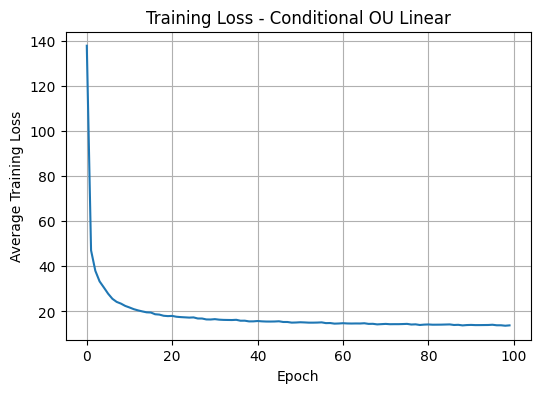

In [73]:
# --------------------------------------------------
# Loss curve
# --------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(loss_history_linear)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss - Conditional OU Linear")
plt.grid(True)
plt.show()

In [74]:
# --------------------------------------------------
# Conditional sampling: generate digits 0-9
# --------------------------------------------------
score_model_ou_linear_cond.load_state_dict(
    torch.load("best_check_point_ou_linear_conditional.pth", map_location=device)
)
score_model_ou_linear_cond.eval()

n_images = 10
T = 1.0
eps = 1.0e-3
n_steps = 500

y_cond = torch.arange(10, device=device)

torch.manual_seed(42)
x_T = torch.randn(n_images, 1, 28, 28, device=device)

with torch.no_grad():
    times_linear, synthetic_images_linear = dfp.euler_maruyama_integrator(
        x_0=x_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_ou_linear_conditional,
            beta_fn=beta_fn,
            score_model=score_model_ou_linear_cond,
            y=y_cond,
        ),
        diffusion_coefficient=diffusion_coefficient,
    )

C:\Users\sandr\AppData\Local\Temp\ipykernel_22212\712088781.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_check_point_ou_linear_conditional.pth", map_

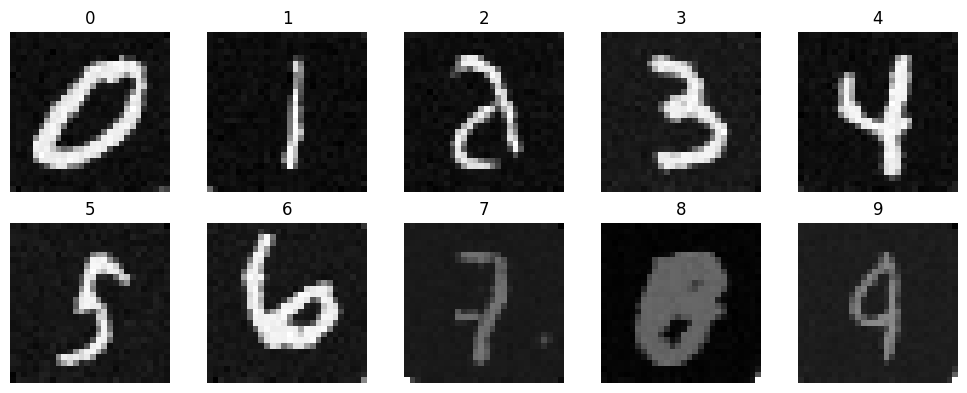

In [75]:
# --------------------------------------------------
# Visualization: digits 0-9
# --------------------------------------------------
samples_linear = synthetic_images_linear[..., -1].detach().cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(samples_linear[i, 0], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(str(i))

plt.tight_layout()
plt.show()

In [76]:
# --------------------------------------------------
# FOR EXERCISE 3: OU linear conditional model objects
# --------------------------------------------------
drift_ou_linear = drift_coefficient
diffusion_ou_linear = diffusion_coefficient
sigma_ou_linear = sigma_t

### COSINE

In [30]:
# 2. USING THE COSINE NOISE SCHEDULE
# --------------------------------------------------
# Cosine noise schedule for the OU / VP process
# --------------------------------------------------

cosine_s = 0.008
beta_clip_max = 50.0

def alpha_bar_cosine(t, s=0.008):
    theta_t = (t + s) / (1.0 + s) * (np.pi / 2.0)
    theta_0 = s / (1.0 + s) * (np.pi / 2.0)
    return (torch.cos(theta_t) ** 2) / (np.cos(theta_0) ** 2)

def alpha_cosine(t, s=0.008):
    return torch.sqrt(alpha_bar_cosine(t, s=s))

def beta_cosine(t, s=0.008, beta_clip_max=20.0):
    theta_t = (t + s) / (1.0 + s) * (np.pi / 2.0)
    beta_t = (np.pi / (1.0 + s)) * torch.tan(theta_t)
    return torch.clamp(beta_t, max=beta_clip_max)

beta_fn = partial(beta_cosine, s=cosine_s, beta_clip_max=beta_clip_max)
alpha_fn = partial(alpha_cosine, s=cosine_s)
alpha_bar_fn = partial(alpha_bar_cosine, s=cosine_s)

drift_coefficient = partial(ou_drift_coefficient, beta_fn=beta_fn)
diffusion_coefficient = partial(ou_diffusion_coefficient, beta_fn=beta_fn)
mu_t = partial(ou_mu_t, alpha_fn=alpha_fn)
sigma_t = partial(ou_sigma_t, alpha_fn=alpha_fn)

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

In [31]:
# --------------------------------------------------
# Mathematical checks
# --------------------------------------------------

t_test = torch.tensor([0.0, 0.25, 0.5, 0.75, 0.999])

print("beta(t):", beta_fn(t_test))
print("alpha_bar(t):", alpha_bar_fn(t_test))
print("alpha(t):", alpha_fn(t_test))
print("sigma_t:", sigma_t(t_test))
print("alpha_bar(t) + sigma_t(t)^2:", alpha_bar_fn(t_test) + sigma_t(t_test)**2)

beta(t): tensor([3.8856e-02, 1.3252e+00, 3.1558e+00, 7.5911e+00, 5.0000e+01])
alpha_bar(t): tensor([1.0000e+00, 8.4701e-01, 4.9384e-01, 1.4427e-01, 2.4289e-06])
alpha(t): tensor([1.0000, 0.9203, 0.7027, 0.3798, 0.0016])
sigma_t: tensor([3.4527e-04, 3.9114e-01, 7.1145e-01, 9.2506e-01, 1.0000e+00])
alpha_bar(t) + sigma_t(t)^2: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [32]:
# --------------------------------------------------
# Define conditional score model
# --------------------------------------------------
score_model_ou_cosine_cond = ConditionalScoreNet(
    marginal_prob_std=sigma_t,
    in_channels=1,
    num_classes=10
).to(device)

x_batch, y_batch = next(iter(DataLoader(data_train, batch_size=8, shuffle=True)))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

loss_test = conditional_loss_function(
    diffusion_process,
    score_model_ou_cosine_cond,
    x_batch,
    y_batch
)

print("Initial test loss:", loss_test.item())

Initial test loss: 4429.845703125


In [33]:
# --------------------------------------------------
# Reverse SDE drift for conditional OU cosine
# --------------------------------------------------
def backward_drift_ou_cosine_conditional(x_t, t, beta_fn, score_model, y):
    beta_t = beta_fn(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t - beta_t * score_model(x_t, t, y)

In [34]:
# --------------------------------------------------
# FOR FID: generate OU cosine conditional samples
# --------------------------------------------------
def generate_ou_cosine_conditional_samples(
    score_model,
    n_samples=300,
    T=0.999,
    eps=1e-3,
    n_steps=200,
    batch_size=64,
):
    score_model.eval()
    all_samples = []

    num_batches = int(np.ceil(n_samples / batch_size))

    for batch_idx in range(num_batches):
        current_batch_size = min(batch_size, n_samples - batch_idx * batch_size)

        y = (torch.arange(current_batch_size, device=device) + batch_idx * batch_size) % 10

        torch.manual_seed(42 + batch_idx)
        x_T = torch.randn(current_batch_size, 1, 28, 28, device=device)

        with torch.no_grad():
            _, synthetic_images = dfp.euler_maruyama_integrator(
                x_0=x_T,
                t_0=T,
                t_end=eps,
                n_steps=n_steps,
                drift_coefficient=partial(
                    backward_drift_ou_cosine_conditional,
                    beta_fn=beta_fn,
                    score_model=score_model,
                    y=y,
                ),
                diffusion_coefficient=diffusion_coefficient,
            )

        samples = synthetic_images[..., -1]
        samples = torch.clamp(samples, 0.0, 1.0)

        all_samples.append(samples.detach().cpu())

    return torch.cat(all_samples, dim=0)[:n_samples]

In [35]:
# --------------------------------------------------
# Training + FID evolution
# --------------------------------------------------
batch_size = 64

data_loader_cosine = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

learning_rate = 1e-3
optimizer = Adam(score_model_ou_cosine_cond.parameters(), lr=learning_rate)

n_epochs = 100
tqdm_epoch = trange(n_epochs)

loss_history_cosine = []
best_loss = float("inf")

fid_history_cosine = []
fid_epochs_cosine = []

for epoch in tqdm_epoch:
    score_model_ou_cosine_cond.train()
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader_cosine:
        x = x.to(device)
        y = y.to(device)

        loss = conditional_loss_function(
            diffusion_process,
            score_model_ou_cosine_cond,
            x,
            y
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history_cosine.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(
            score_model_ou_cosine_cond.state_dict(),
            "best_check_point_ou_cosine_conditional.pth"
        )

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:.6f}")

    # --------------------------------------------
    # FID
    # --------------------------------------------
    if (epoch + 1) % 10 == 0:
        gen_cosine = generate_ou_cosine_conditional_samples(
            score_model=score_model_ou_cosine_cond,
            n_samples=300,
            T=0.999,
            eps=1e-3,
            n_steps=200,
            batch_size=64,
        )

        gen_features = get_features_from_tensor(
            gen_cosine,
            feature_extractor,
            device,
            batch_size=64
        )

        mu_gen, sigma_gen_stats = compute_statistics(gen_features)

        fid_value = calculate_fid_from_stats(
            mu_real,
            sigma_real_stats,
            mu_gen,
            sigma_gen_stats
        )

        fid_history_cosine.append(fid_value)
        fid_epochs_cosine.append(epoch + 1)

        print(f"Epoch {epoch + 1} | FID OU cosine: {fid_value:.4f}")

torch.save(
    score_model_ou_cosine_cond.state_dict(),
    "check_point_ou_cosine_conditional.pth"
)

Average Loss: 34.021727:  10%|█         | 10/100 [02:16<24:41, 16.46s/it]

Epoch 10 | FID OU cosine: 71.2973


Average Loss: 28.658896:  20%|██        | 20/100 [04:34<21:52, 16.41s/it]

Epoch 20 | FID OU cosine: 74.4227


Average Loss: 26.677626:  30%|███       | 30/100 [06:49<18:24, 15.77s/it]

...

Epoch 80 | FID OU cosine: 59.2495


Average Loss: 23.473969:  90%|█████████ | 90/100 [19:53<02:34, 15.42s/it]

Epoch 90 | FID OU cosine: 59.9252


Average Loss: 23.430675: 100%|██████████| 100/100 [22:04<00:00, 13.25s/it]

Epoch 100 | FID OU cosine: 59.9499


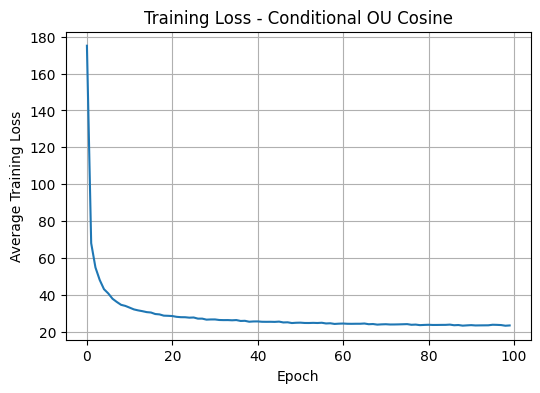

In [36]:
# --------------------------------------------------
# Loss curve
# --------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(loss_history_cosine)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss - Conditional OU Cosine")
plt.grid(True)
plt.show()

In [37]:
# --------------------------------------------------
# Conditional sampling / generation: digits 0-9
# --------------------------------------------------
score_model_ou_cosine_cond.load_state_dict(
    torch.load("best_check_point_ou_cosine_conditional.pth", map_location=device)
)
score_model_ou_cosine_cond.eval()

n_images = 10
T = 0.999
eps = 1.0e-3
n_steps = 500

y_cond = torch.arange(10, device=device)

torch.manual_seed(42)
x_T = torch.randn(n_images, 1, 28, 28, device=device)

with torch.no_grad():
    times_cosine, synthetic_images_cosine = dfp.euler_maruyama_integrator(
        x_0=x_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_ou_cosine_conditional,
            beta_fn=beta_fn,
            score_model=score_model_ou_cosine_cond,
            y=y_cond,
        ),
        diffusion_coefficient=diffusion_coefficient,
    )

print(synthetic_images_cosine.shape)

C:\Users\sandr\AppData\Local\Temp\ipykernel_22212\927976642.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_check_point_ou_cosine_conditional.pth", map_

torch.Size([10, 1, 28, 28, 501])


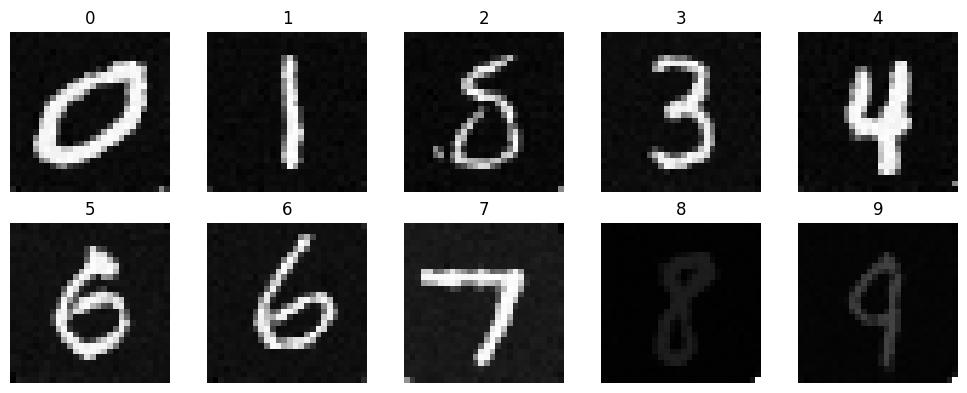

In [38]:
# --------------------------------------------------
# Visualization: final digits 0-9
# --------------------------------------------------
samples_cosine = synthetic_images_cosine[..., -1].detach().cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(samples_cosine[i, 0], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(str(i))

plt.tight_layout()
plt.show()

In [39]:
# --------------------------------------------------
# FOR EXERCISE 3: OU cosine conditional model objects
# --------------------------------------------------
score_model_ou_cosine = score_model_ou_cosine_cond
drift_ou_cosine = drift_coefficient
diffusion_ou_cosine = diffusion_coefficient
sigma_ou_cosine = sigma_t
T_ou_cosine = 0.999

#### QUADRATIC

In [40]:
# 3. Using a third noise schedule of your choice. -> quadratic noise schedule.
# El quadratic schedule suele estar “entre” el linear y el cosine: más suave que el lineal al principio, menos problemático que el cosine al final, bastante razonable para comparar
# --------------------------------------------------
# Quadratic noise schedule for the OU / VP process
# --------------------------------------------------

beta_min = 0.1
beta_max = 20.0

def beta_quadratic(t, beta_min, beta_max):
    return beta_min + (beta_max - beta_min) * t**2

def A_quadratic(t, beta_min, beta_max):
    return beta_min * t + (beta_max - beta_min) * t**3 / 3.0

def alpha_quadratic(t, beta_min, beta_max):
    return torch.exp(-0.5 * A_quadratic(t, beta_min, beta_max))

beta_fn = partial(beta_quadratic, beta_min=beta_min, beta_max=beta_max)
alpha_fn = partial(alpha_quadratic, beta_min=beta_min, beta_max=beta_max)

drift_coefficient = partial(ou_drift_coefficient, beta_fn=beta_fn)
diffusion_coefficient = partial(ou_diffusion_coefficient, beta_fn=beta_fn)
mu_t = partial(ou_mu_t, alpha_fn=alpha_fn)
sigma_t = partial(ou_sigma_t, alpha_fn=alpha_fn)

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

In [41]:
# --------------------------------------------------
# Mathematical checks
# --------------------------------------------------
t_test = torch.tensor([0.0, 0.25, 0.5, 0.75, 1.0])

print("beta(t):", beta_fn(t_test))
print("A(t):", A_quadratic(t_test, beta_min, beta_max))
print("alpha(t):", alpha_fn(t_test))
print("sigma_t:", sigma_t(t_test))
print("alpha(t)^2 + sigma_t(t)^2:", alpha_fn(t_test)**2 + sigma_t(t_test)**2)

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

beta(t): tensor([ 0.1000,  1.3438,  5.0750, 11.2937, 20.0000])
A(t): tensor([0.0000, 0.1286, 0.8792, 2.8734, 6.7333])
alpha(t): tensor([1.0000, 0.9377, 0.6443, 0.2377, 0.0345])
sigma_t: tensor([0.0000, 0.3474, 0.7648, 0.9713, 0.9994])
alpha(t)^2 + sigma_t(t)^2: tensor([1., 1., 1., 1., 1.])


In [42]:
# --------------------------------------------------
# Conditional score model
# --------------------------------------------------
score_model_ou_quadratic_cond = ConditionalScoreNet(
    marginal_prob_std=sigma_t,
    in_channels=1,
    num_classes=10
).to(device)

x_batch, y_batch = next(iter(DataLoader(data_train, batch_size=8, shuffle=True)))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

loss_test = conditional_loss_function(
    diffusion_process,
    score_model_ou_quadratic_cond,
    x_batch,
    y_batch
)

print(loss_test)

tensor(4427.6846, device='cuda:0', grad_fn=<MeanBackward0>)


In [43]:
def backward_drift_ou_quadratic_conditional(x_t, t, beta_fn, score_model, y):
    beta_t = beta_fn(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t - beta_t * score_model(x_t, t, y)

In [44]:
# --------------------------------------------------
# FOR FID: generate OU quadratic conditional samples
# --------------------------------------------------

def generate_ou_quadratic_conditional_samples(
    score_model,
    n_samples=300,
    T=1.0,
    eps=1e-3,
    n_steps=200,
    batch_size=64,
):
    score_model.eval()
    all_samples = []

    num_batches = int(np.ceil(n_samples / batch_size))

    for batch_idx in range(num_batches):
        current_batch_size = min(batch_size, n_samples - batch_idx * batch_size)

        y = (torch.arange(current_batch_size, device=device) + batch_idx * batch_size) % 10

        torch.manual_seed(42 + batch_idx)
        x_T = torch.randn(current_batch_size, 1, 28, 28, device=device)

        with torch.no_grad():
            _, synthetic_images = dfp.euler_maruyama_integrator(
                x_0=x_T,
                t_0=T,
                t_end=eps,
                n_steps=n_steps,
                drift_coefficient=partial(
                    backward_drift_ou_quadratic_conditional,
                    beta_fn=beta_fn,
                    score_model=score_model,
                    y=y,
                ),
                diffusion_coefficient=diffusion_coefficient,
            )

        samples = synthetic_images[..., -1]
        samples = torch.clamp(samples, 0.0, 1.0)

        all_samples.append(samples.detach().cpu())

    return torch.cat(all_samples, dim=0)[:n_samples]

In [45]:
# --------------------------------------------------
# Training
# --------------------------------------------------
batch_size = 64

data_loader_quadratic = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

learning_rate = 1e-3
optimizer = Adam(score_model_ou_quadratic_cond.parameters(), lr=learning_rate)

n_epochs = 100
tqdm_epoch = trange(n_epochs)

loss_history_quadratic = []
best_loss = float("inf")

fid_history_quadratic = []
fid_epochs_quadratic = []

for epoch in tqdm_epoch:
    score_model_ou_quadratic_cond.train()
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader_quadratic:
        x = x.to(device)
        y = y.to(device)

        loss = conditional_loss_function(
            diffusion_process,
            score_model_ou_quadratic_cond,
            x,
            y
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history_quadratic.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(
            score_model_ou_quadratic_cond.state_dict(),
            "best_check_point_ou_quadratic_conditional.pth"
        )

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:.5f}")

    # --------------------------------------------
    # FID
    # --------------------------------------------
    if (epoch + 1) % 10 == 0:
        gen_quadratic = generate_ou_quadratic_conditional_samples(
            score_model=score_model_ou_quadratic_cond,
            n_samples=300,
            T=1.0,
            eps=1e-3,
            n_steps=200,
            batch_size=64,
        )

        gen_features = get_features_from_tensor(
            gen_quadratic,
            feature_extractor,
            device,
            batch_size=64
        )

        mu_gen, sigma_gen_stats = compute_statistics(gen_features)

        fid_value = calculate_fid_from_stats(
            mu_real,
            sigma_real_stats,
            mu_gen,
            sigma_gen_stats
        )

        fid_history_quadratic.append(fid_value)
        fid_epochs_quadratic.append(epoch + 1)

        print(f"Epoch {epoch + 1} | FID OU quadratic: {fid_value:.4f}")

torch.save(
    score_model_ou_quadratic_cond.state_dict(),
    "check_point_ou_quadratic_conditional.pth"
)

Average Loss: 33.27526:  10%|█         | 10/100 [02:11<23:54, 15.94s/it]

Epoch 10 | FID OU quadratic: 96.1998


Average Loss: 28.45185:  20%|██        | 20/100 [04:25<21:19, 16.00s/it]

Epoch 20 | FID OU quadratic: 77.2281


Average Loss: 26.53115:  30%|███       | 30/100 [06:38<18:22, 15.74s/it]

...

Epoch 80 | FID OU quadratic: 70.1014


Average Loss: 23.42833:  90%|█████████ | 90/100 [19:53<02:35, 15.56s/it]

Epoch 90 | FID OU quadratic: 71.3545


Average Loss: 23.23206: 100%|██████████| 100/100 [22:06<00:00, 13.26s/it]

Epoch 100 | FID OU quadratic: 71.1182


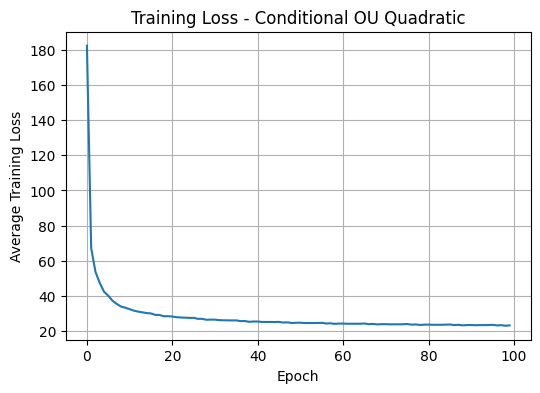

In [46]:
# --------------------------------------------------
# Loss curve
# --------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(loss_history_quadratic)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss - Conditional OU Quadratic")
plt.grid(True)
plt.show()

In [47]:
# --------------------------------------------------
# Conditional sampling / generation: digits 0-9
# --------------------------------------------------
score_model_ou_quadratic_cond.load_state_dict(
    torch.load("best_check_point_ou_quadratic_conditional.pth", map_location=device)
)
score_model_ou_quadratic_cond.eval()

n_images = 10
T = 1.0
eps = 1e-3
n_steps = 500

y_cond = torch.arange(10, device=device)

torch.manual_seed(42)
x_T = torch.randn(n_images, 1, 28, 28, device=device)

with torch.no_grad():
    times_quadratic, synthetic_images_quadratic = dfp.euler_maruyama_integrator(
        x_0=x_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_ou_quadratic_conditional,
            beta_fn=beta_fn,
            score_model=score_model_ou_quadratic_cond,
            y=y_cond,
        ),
        diffusion_coefficient=diffusion_coefficient,
    )

print(synthetic_images_quadratic.shape)

C:\Users\sandr\AppData\Local\Temp\ipykernel_22212\458493014.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_check_point_ou_quadratic_conditional.pth", m

torch.Size([10, 1, 28, 28, 501])


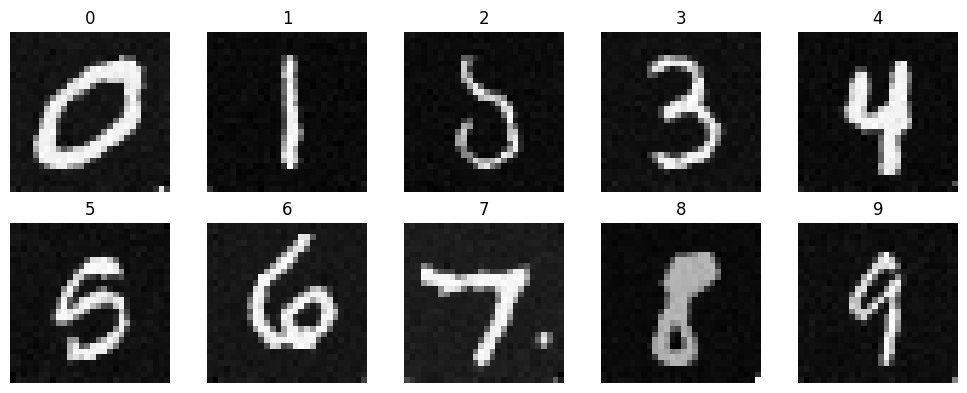

In [48]:
# --------------------------------------------------
# Visualization: final digits 0-9
# --------------------------------------------------
samples_quadratic = synthetic_images_quadratic[..., -1].detach().cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(samples_quadratic[i, 0], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(str(i))

plt.tight_layout()
plt.show()

In [49]:
# --------------------------------------------------
# FOR EXERCISE 3: OU quadratic conditional model objects
# --------------------------------------------------
score_model_ou_quadratic = score_model_ou_quadratic_cond
drift_ou_quadratic = drift_coefficient
diffusion_ou_quadratic = diffusion_coefficient
sigma_ou_quadratic = sigma_t
T_ou_quadratic = 1.0

## Exercise 3: Evaluation of the quality of the generated images

1. Describe, and compare the characteristics, advantages, and disadvantages of the following measures of quality for generative IA models for images:
---

**1. The negative log-likelihood (NLL).**

The negative log-likelihood (NLL) measures how well a probabilistic model explains the data. It is defined as

$$
\mathrm{NLL}
=
- \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}
\left[
\log p_\theta(\mathbf{x})
\right].
$$

For a dataset, it is approximated as

$$
\mathrm{NLL}
=
- \frac{1}{N} \sum_{i=1}^{N} \log p_\theta(\mathbf{x}_i).
$$

A lower NLL indicates that the model assigns higher probability to the data.

In diffusion models, the likelihood is not computed directly but is typically estimated using techniques such as the probability flow ODE or variational approximations.

**Advantages:**

- It has a clear probabilistic interpretation.
- It is suitable for likelihood-based models such as diffusion models.

**Disadvantages:**

- It does not always correlate with visual quality.
- It can be difficult to compute exactly in complex models.

---

**2. Bits per dimension (BPD).**
The bits per dimension (BPD) is a normalized version of the negative log-likelihood. It is defined as

$$
\mathrm{BPD}
=
\frac{- \log p_\theta(\mathbf{x})}{D \cdot \log 2},
$$

where \( D \) is the number of dimensions (e.g., number of pixels).

It measures how many bits are required to encode each dimension of the data.

**Advantages:**

- Allows comparison across datasets and models.
- It is a standard metric in generative modeling.
- It normalizes by dimensionality, making it especially useful for images.

**Disadvantages:**

- Shares the same limitations as the NLL.
- It is difficult to interpret in terms of visual quality.

---

**3. Fréchet Inception Distance (FID).**

The Fréchet Inception Distance (FID) compares the distributions of real and generated images in a feature space obtained from a pretrained Inception network. It is defined as

$$
\mathrm{FID}
=
\|\mu_r - \mu_g\|^2
+
\mathrm{Tr}\left(
\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}
\right),
$$

where:

- \( \mu_r \), \( \Sigma_r \) are the mean and covariance of real data features,
- \( \mu_g \), \( \Sigma_g \) are the mean and covariance of generated data features.

A lower FID indicates better quality and diversity of the generated images.

**Advantages:**

- Correlates well with human perception.
- Captures both image quality and diversity.

**Disadvantages:**

- Depends on a pretrained network (Inception).
- Not a likelihood-based metric.
- May be sensitive to implementation details and dataset size.

---

**4. Structural Similarity Index Measure (SSIM)**

The Structural Similarity Index Measure (SSIM) evaluates the similarity between two images based on luminance, contrast, and structure. It is defined as

$$
\mathrm{SSIM}(x, y)
=
\frac{(2\mu_x \mu_y + C_1)(2\sigma_{xy} + C_2)}
{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)},
$$

where:

- \( \mu_x, \mu_y \) are the means,
- \( \sigma_x^2, \sigma_y^2 \) are the variances,
- \( \sigma_{xy} \) is the covariance.

**Advantages:**

- Measures perceptual similarity between images.
- Sensitive to structural information.

**Disadvantages:**

- Requires reference images.
- Not suitable as a standalone metric for generative models.

-------------------------------------------------------------------------

2. Compare using BPD the different diffusion models (Brownian motion, Ornstein-Uhlenbeck), noising schedules (linear, cosine, etc.), and sampling strategies (SDE, ODE) implemented.

In [77]:
import torch
import numpy as np

def gaussian_logpdf_general(x, std):
    """
    Log-density of N(0, std^2 I).
    """
    dim = x[0].numel()
    x_flat = x.view(x.shape[0], -1)
    var = std.view(-1) ** 2

    return -0.5 * (
        dim * torch.log(torch.tensor(2 * np.pi, device=x.device))
        + dim * torch.log(var)
        + torch.sum(x_flat ** 2, dim=1) / var
    )


def divergence_hutchinson_general(fn, x, t):
    """
    Hutchinson estimator:
        div f(x) ≈ eps^T J_f(x) eps
    """
    eps = torch.randn_like(x)
    x.requires_grad_(True)

    y = fn(x, t)
    inner = torch.sum(y * eps)

    grad = torch.autograd.grad(inner, x, create_graph=False)[0]
    div = torch.sum(grad * eps, dim=(1, 2, 3))

    return div


def make_probability_flow_drift_conditional(
    drift_coefficient,
    diffusion_coefficient,
    score_model,
    y
):
    """
    Conditional probability flow ODE drift:

        f_tilde(x,t,y) = f(x,t) - 0.5 g(t)^2 s_theta(x,t,y)
    """
    def probability_flow_drift(x_t, t):
        g_t = diffusion_coefficient(t).view(-1, 1, 1, 1)
        return drift_coefficient(x_t, t) - 0.5 * (g_t ** 2) * score_model(x_t, t, y)

    return probability_flow_drift


def compute_log_likelihood_conditional(
    x_data,
    y_data,
    score_model,
    drift_coefficient,
    diffusion_coefficient,
    sigma_t,
    T=1.0,
    eps=1e-3,
    n_steps=100,
):
    """
    Approximate conditional log-likelihood log p_0(x | y)
    using the probability flow ODE.
    """
    score_model.eval()

    device = x_data.device
    batch_size = x_data.shape[0]

    y_data = y_data.to(device)

    probability_flow_drift = make_probability_flow_drift_conditional(
        drift_coefficient=drift_coefficient,
        diffusion_coefficient=diffusion_coefficient,
        score_model=score_model,
        y=y_data,
    )

    times = torch.linspace(eps, T, n_steps + 1, device=device)
    dt = times[1] - times[0]

    x = x_data.clone().to(device)
    delta_logp = torch.zeros(batch_size, device=device)

    for t_scalar in times[:-1]:
        t_batch = torch.ones(batch_size, device=device) * t_scalar

        x = x.detach().requires_grad_(True)

        drift = probability_flow_drift(x, t_batch)
        div = divergence_hutchinson_general(probability_flow_drift, x, t_batch)

        x = (x + drift * dt).detach()

        # d log p / dt = - div f_tilde
        delta_logp = delta_logp - div.detach() * dt

    sigma_T = sigma_t(
        torch.ones(batch_size, device=device) * T
    ).view(-1, 1, 1, 1)

    log_pT = gaussian_logpdf_general(x, sigma_T)

    log_p0 = log_pT + delta_logp

    return log_p0


def loglik_to_bpd(log_likelihood, x):
    """
    Convert log-likelihood to bits per dimension.
    """
    num_dims = x[0].numel()
    return -log_likelihood / (num_dims * np.log(2))


def evaluate_bpd_full_conditional(
    model_name,
    score_model,
    drift_coefficient,
    diffusion_coefficient,
    sigma_t,
    test_loader,
    T=1.0,
    eps=1e-3,
    n_steps=100,
    max_batches=50,
):
    all_loglik = []
    all_bpd = []

    for i, (x_batch, y_batch) in enumerate(test_loader):
        if i >= max_batches:
            break

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        log_likelihoods = compute_log_likelihood_conditional(
            x_data=x_batch,
            y_data=y_batch,
            score_model=score_model,
            drift_coefficient=drift_coefficient,
            diffusion_coefficient=diffusion_coefficient,
            sigma_t=sigma_t,
            T=T,
            eps=eps,
            n_steps=n_steps,
        )

        bpd_values = loglik_to_bpd(log_likelihoods, x_batch)

        all_loglik.append(log_likelihoods.detach().cpu())
        all_bpd.append(bpd_values.detach().cpu())

    all_loglik = torch.cat(all_loglik)
    all_bpd = torch.cat(all_bpd)

    return {
        "model": model_name,
        "mean_loglik": all_loglik.mean().item(),
        "mean_bpd": all_bpd.mean().item(),
    }

In [78]:
results_bpd = []

results_bpd.append(
    evaluate_bpd_full_conditional(
        "Brownian motion conditional",
        score_model_brownian_cond,
        drift_brownian,
        diffusion_brownian,
        sigma_brownian,
        data_loader_full,
        T=1.0,
        eps=1e-3,
        n_steps=500,
        max_batches=64,
    )
)

In [79]:
# OU linear
results_bpd.append(
    evaluate_bpd_full_conditional(
        "OU - linear conditional",
        score_model_ou_linear_cond,
        drift_ou_linear,
        diffusion_ou_linear,
        sigma_ou_linear,
        data_loader_linear,
        T=1.0,
        eps=1e-3,
        n_steps=100,
        max_batches=50,
    )
)

In [80]:
# OU cosine
results_bpd.append(
    evaluate_bpd_full_conditional(
        "OU - cosine conditional",
        score_model_ou_cosine,
        drift_ou_cosine,
        diffusion_ou_cosine,
        sigma_ou_cosine,
        data_loader_cosine,
        T=0.999,
        eps=1e-3,
        n_steps=100,
        max_batches=50,
    )
)

In [81]:
# OU quadratic
results_bpd.append(
    evaluate_bpd_full_conditional(
        "OU - quadratic conditional",
        score_model_ou_quadratic,
        drift_ou_quadratic,
        diffusion_ou_quadratic,
        sigma_ou_quadratic,
        data_loader_quadratic,
        T=1.0,
        eps=1e-3,
        n_steps=100,
        max_batches=50,
    )
)

In [82]:
import pandas as pd

df_bpd = pd.DataFrame(results_bpd)
df_bpd = df_bpd.sort_values("mean_bpd", ascending=True).reset_index(drop=True)

display(df_bpd)

,model,mean_loglik,mean_bpd
0,OU - linear conditional,-5949.716797,10.948503
1,OU - quadratic conditional,-6029.747559,11.095774
2,OU - cosine conditional,-6150.620605,11.318203
3,Brownian motion conditional,-7114.370117,13.091668


The obtained results are consistent with the expected qualitative behavior of the considered diffusion processes. The Brownian motion model yields the highest BPD, which suggests a poorer approximation of the data distribution. In contrast, the Ornstein-Uhlenbeck models achieve significantly lower BPD values, indicating a more accurate likelihood-based fit.

Within the OU family, the linear schedule provides the best performance in this experiment, although the cosine schedule is very close, and the quadratic schedule remains in the same general range. Therefore, while the exact ranking among OU schedules may depend on optimization details and numerical approximation errors, the overall conclusion is clear: the OU-based models outperform the Brownian motion model on full MNIST according to the BPD metric.

## FID (Fréchet Inception Distance)

* **Brownian**

In [83]:
# --------------------------------------------------
# Compute FID for Brownian conditional model
# --------------------------------------------------

# Generated samples
gen_brownian = generate_brownian_conditional_samples(
    score_model=score_model_brownian_cond,
    n_samples=500,
    T=1.0,
    eps=1e-3,
    n_steps=500,
    batch_size=64,
)

gen_features = get_features_from_tensor(
    gen_brownian,
    feature_extractor,
    device,
    batch_size=64
)

mu_gen, sigma_gen_stats = compute_statistics(gen_features)

fid_brownian = calculate_fid_from_stats(
    mu_real,
    sigma_real_stats,
    mu_gen,
    sigma_gen_stats
)

print("FID Brownian conditional:", fid_brownian)

FID Brownian conditional: 106.14222416994392


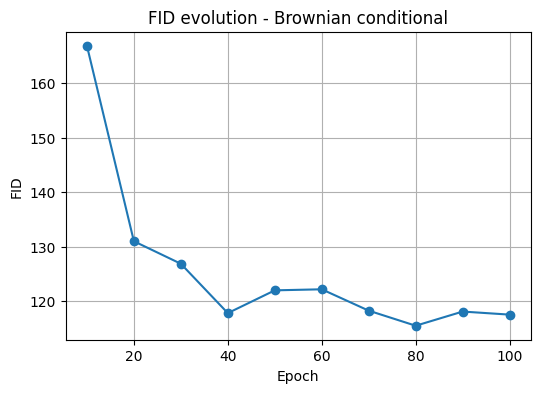

In [84]:
plt.figure(figsize=(6, 4))
plt.plot(fid_epochs_brownian, fid_history_brownian, marker="o")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID evolution - Brownian conditional")
plt.grid(True)
plt.show()

* **OU Linear**

In [85]:
# --------------------------------------------------
# Compute FID for OU linear conditional model
# --------------------------------------------------

gen_linear = generate_ou_linear_conditional_samples(
    score_model=score_model_ou_linear_cond,
    n_samples=500,
    T=1.0,
    eps=1e-3,
    n_steps=500,
    batch_size=64,
)

gen_features = get_features_from_tensor(
    gen_linear,
    feature_extractor,
    device,
    batch_size=64
)

mu_gen, sigma_gen_stats = compute_statistics(gen_features)

fid_linear = calculate_fid_from_stats(
    mu_real,
    sigma_real_stats,
    mu_gen,
    sigma_gen_stats
)

print("FID OU linear conditional:", fid_linear)

FID OU linear conditional: 58.974130195840985


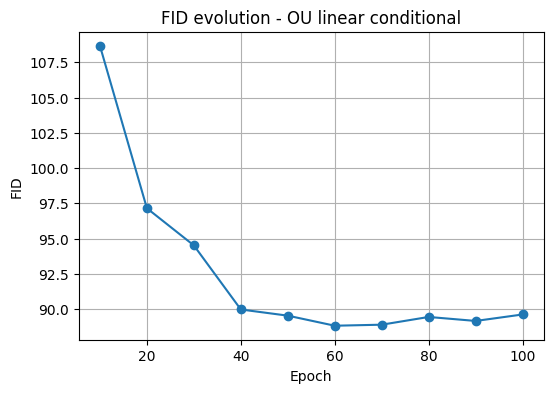

In [86]:
plt.figure(figsize=(6, 4))
plt.plot(fid_epochs_linear, fid_history_linear, marker="o")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID evolution - OU linear conditional")
plt.grid(True)
plt.show()

* **OU Cosine**

In [87]:
# --------------------------------------------------
# Compute FID for OU cosine conditional model
# --------------------------------------------------

gen_cosine = generate_ou_cosine_conditional_samples(
    score_model=score_model_ou_cosine_cond,
    n_samples=500,
    T=0.999,
    eps=1e-3,
    n_steps=500,
    batch_size=64,
)

gen_features = get_features_from_tensor(
    gen_cosine,
    feature_extractor,
    device,
    batch_size=64
)

mu_gen, sigma_gen_stats = compute_statistics(gen_features)

fid_cosine = calculate_fid_from_stats(
    mu_real,
    sigma_real_stats,
    mu_gen,
    sigma_gen_stats
)

print("FID OU cosine conditional:", fid_cosine)

FID OU cosine conditional: 111.09688359867005


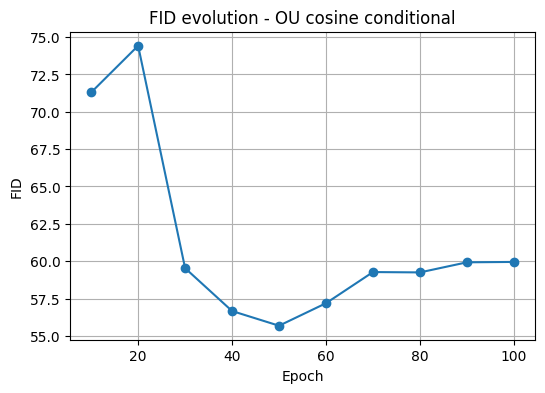

In [88]:
plt.figure(figsize=(6, 4))
plt.plot(fid_epochs_cosine, fid_history_cosine, marker="o")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID evolution - OU cosine conditional")
plt.grid(True)
plt.show()

* **U Quadratic**

In [89]:
# --------------------------------------------------
# Compute FID for OU quadratic conditional model
# --------------------------------------------------

gen_quadratic = generate_ou_quadratic_conditional_samples(
    score_model=score_model_ou_quadratic_cond,
    n_samples=500,
    T=1.0,
    eps=1e-3,
    n_steps=500,
    batch_size=64,
)

gen_features = get_features_from_tensor(
    gen_quadratic,
    feature_extractor,
    device,
    batch_size=64
)

mu_gen, sigma_gen_stats = compute_statistics(gen_features)

fid_quadratic = calculate_fid_from_stats(
    mu_real,
    sigma_real_stats,
    mu_gen,
    sigma_gen_stats
)

print("FID OU quadratic conditional:", fid_quadratic)

FID OU quadratic conditional: 102.21963449351611


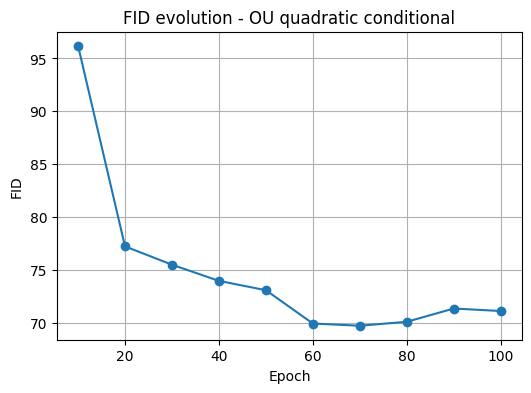

In [90]:
plt.figure(figsize=(6, 4))
plt.plot(fid_epochs_quadratic, fid_history_quadratic, marker="o")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID evolution - OU quadratic conditional")
plt.grid(True)
plt.show()